# Crypto Bot Trading Strategy

Интерактивный анализ стратегии крипто-бота на Polymarket.

**Секции:**
1. **Данные** — Deribit (IV, фьючерсы), Binance (спот), Polymarket (BTC/ETH рынки)
2. **Модель Student-t** — калибровка fat tails, сравнение с нормальным распределением
3. **Текущие возможности** — edge и ROI по всем рынкам

In [1]:
import sys
sys.path.insert(0, '.')

import json
import math
import ssl
import urllib.request
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t as student_t
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

_ctx = ssl.create_default_context()
_ctx.check_hostname = False
_ctx.verify_mode = ssl.CERT_NONE

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

---
## 1. Данные

### 1.1 Deribit — фьючерсная кривая + IV

In [2]:
from trading_bot.market_data.deribit import DeribitData

deribit = DeribitData()
out_deribit = widgets.Output()

def show_deribit():
    with out_deribit:
        clear_output(wait=True)
        print('Loading Deribit data...')
        deribit.update()
        clear_output(wait=True)

        ts = datetime.now().strftime('%H:%M:%S')
        print(f'BTC: ${deribit.btc_spot:,.0f}  IV: {deribit.btc_iv:.1%}')
        print(f'ETH: ${deribit.eth_spot:,.0f}  IV: {deribit.eth_iv:.1%}')
        print(f'Updated: {ts}')
        print()

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

        for currency, ax, spot in [('BTC', ax1, deribit.btc_spot), ('ETH', ax2, deribit.eth_spot)]:
            curve = deribit.get_curve(currency)
            if not curve:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                continue

            days = [c[0] for c in curve]
            prices = [c[2] for c in curve]
            drifts = [c[1] for c in curve]
            names = [c[3].split('-')[1] for c in curve]  # e.g. '6MAR26'

            ax.plot(days, prices, 'o-', color='steelblue', markersize=6, linewidth=1.5)
            ax.axhline(y=spot, color='red', linewidth=0.8, linestyle='--', alpha=0.6, label=f'Spot ${spot:,.0f}')

            for i, (d, p, dr, nm) in enumerate(zip(days, prices, drifts, names)):
                ax.annotate(f'{nm}\n{dr:+.1%}/yr', (d, p), textcoords='offset points',
                           xytext=(0, 12), ha='center', fontsize=7, color='gray')

            ax.set_title(f'{currency} Futures Curve', fontsize=11)
            ax.set_xlabel('Days to Expiry')
            ax.set_ylabel('Price ($)')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Table
        for currency in ['BTC', 'ETH']:
            curve = deribit.get_curve(currency)
            if curve:
                print(f'\n{currency} futures:')
                print(f'{"Name":<20} {"Price":>10} {"Days":>6} {"Drift":>10}')
                print('-' * 50)
                for d, drift, price, name in curve:
                    print(f'{name:<20} ${price:>9,.0f} {d:>5}d {drift:>+9.1%}/yr')

btn_deribit = widgets.Button(description='\U0001f504 Refresh Deribit', button_style='info', layout=widgets.Layout(width='180px'))
btn_deribit.on_click(lambda b: show_deribit())
display(btn_deribit, out_deribit)
show_deribit()

Button(button_style='info', description='🔄 Refresh Deribit', layout=Layout(width='180px'), style=ButtonStyle()…

Output()

### 1.2 Binance — цена BTC/ETH

In [3]:
out_binance = widgets.Output()

def show_binance():
    with out_binance:
        clear_output(wait=True)
        try:
            url = 'https://api.binance.com/api/v3/ticker/price?symbols=["BTCUSDT","ETHUSDT"]'
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            resp = urllib.request.urlopen(req, timeout=10, context=_ctx)
            data = json.loads(resp.read())
            prices = {d['symbol']: float(d['price']) for d in data}
            ts = datetime.now().strftime('%H:%M:%S')

            btc = prices.get('BTCUSDT', 0)
            eth = prices.get('ETHUSDT', 0)

            html = f'''
            <div style="font-size: 18px; font-family: monospace; padding: 10px; background: #1a1a2e; color: #eee; border-radius: 8px;">
                <span style="color: #f39c12;">BTC</span> <b>${btc:,.2f}</b> &nbsp;|&nbsp;
                <span style="color: #3498db;">ETH</span> <b>${eth:,.2f}</b> &nbsp;|&nbsp;
                <span style="color: #888; font-size: 12px;">Updated {ts}</span>
            </div>
            '''
            display(HTML(html))
        except Exception as e:
            print(f'Error: {e}')

btn_binance = widgets.Button(description='\U0001f504 Refresh Price', button_style='info', layout=widgets.Layout(width='180px'))
btn_binance.on_click(lambda b: show_binance())
display(btn_binance, out_binance)
show_binance()

Button(button_style='info', description='🔄 Refresh Price', layout=Layout(width='180px'), style=ButtonStyle())

Output()

### 1.3 Polymarket — BTC/ETH рынки

In [4]:
from trading_bot.market_data.polymarket import PolymarketData

pm = PolymarketData(Path('crypto_markets.json'))
out_markets = widgets.Output()

def show_markets():
    with out_markets:
        clear_output(wait=True)
        print('Loading markets from Polymarket...')
        pm.update()
        markets = pm.markets
        clear_output(wait=True)

        active = [m for m in markets if m.days_remaining > 0 and m.yes_price > 0]
        print(f'Loaded: {len(markets)} markets | Active with prices: {len(active)}')
        print()

        # Split by currency
        for currency in ['BTC', 'ETH']:
            cm = sorted([m for m in active if m.currency == currency],
                       key=lambda m: m.strike)
            if not cm:
                continue

            direction_char = lambda m: '\u2191' if m.is_up else '\u2193'
            print(f'=== {currency} ({len(cm)} markets) ===')
            print(f'{"Market":<40} {"Dir":>3} {"Strike":>10} {"YES":>6} {"NO":>6} {"Days":>5}')
            print('-' * 75)
            for m in cm:
                d = direction_char(m)
                print(f'{m.question[:38]:<40} {d:>3} ${m.strike:>9,.0f} '
                      f'{m.yes_price:>5.0%} {1-m.yes_price:>5.0%} {m.days_remaining:>4.0f}d')
            print()

btn_markets = widgets.Button(description='\U0001f504 Refresh Markets', button_style='info', layout=widgets.Layout(width='180px'))
btn_markets.on_click(lambda b: show_markets())
display(btn_markets, out_markets)
show_markets()

Button(button_style='info', description='🔄 Refresh Markets', layout=Layout(width='180px'), style=ButtonStyle()…

Output()

---
## 2. Модель Student-t

### Зачем fat tails?

Крипто-рынки имеют **толстые хвосты** — экстремальные движения (crash/pump) случаются значительно чаще, чем предсказывает нормальное распределение. Это критично для touch probability: нормальное распределение **занижает** вероятность касания далёких страйков.

**Student-t распределение** с малым числом степеней свободы (df) моделирует это:
- **df → ∞** = нормальное распределение (тонкие хвосты)
- **df ≈ 3** = значительно более толстые хвосты
- **df ≈ 2** = очень толстые хвосты (бесконечная дисперсия при df ≤ 2)

Калиброванные значения (1500 дней Deribit perpetual, 2022-02 — 2026-02):
- **BTC: df = 2.61** — более толстые хвосты (больше экстремальных движений)
- **ETH: df = 2.88** — чуть тоньше, но всё ещё далеко от нормального

Fetching BTC daily data...

BTC: 1500 daily returns
  Fitted df = 2.66  (calibrated: 2.61)
  Mean: 0.00044  Std: 0.02689
  Kurtosis: 5.96 (Normal=3)
  Tail weight at 3σ: Student-t is 8.0x heavier than Normal
Fetching ETH daily data...

ETH: 1500 daily returns
  Fitted df = 2.92  (calibrated: 2.88)
  Mean: -0.00013  Std: 0.03639
  Kurtosis: 7.28 (Normal=3)
  Tail weight at 3σ: Student-t is 7.1x heavier than Normal


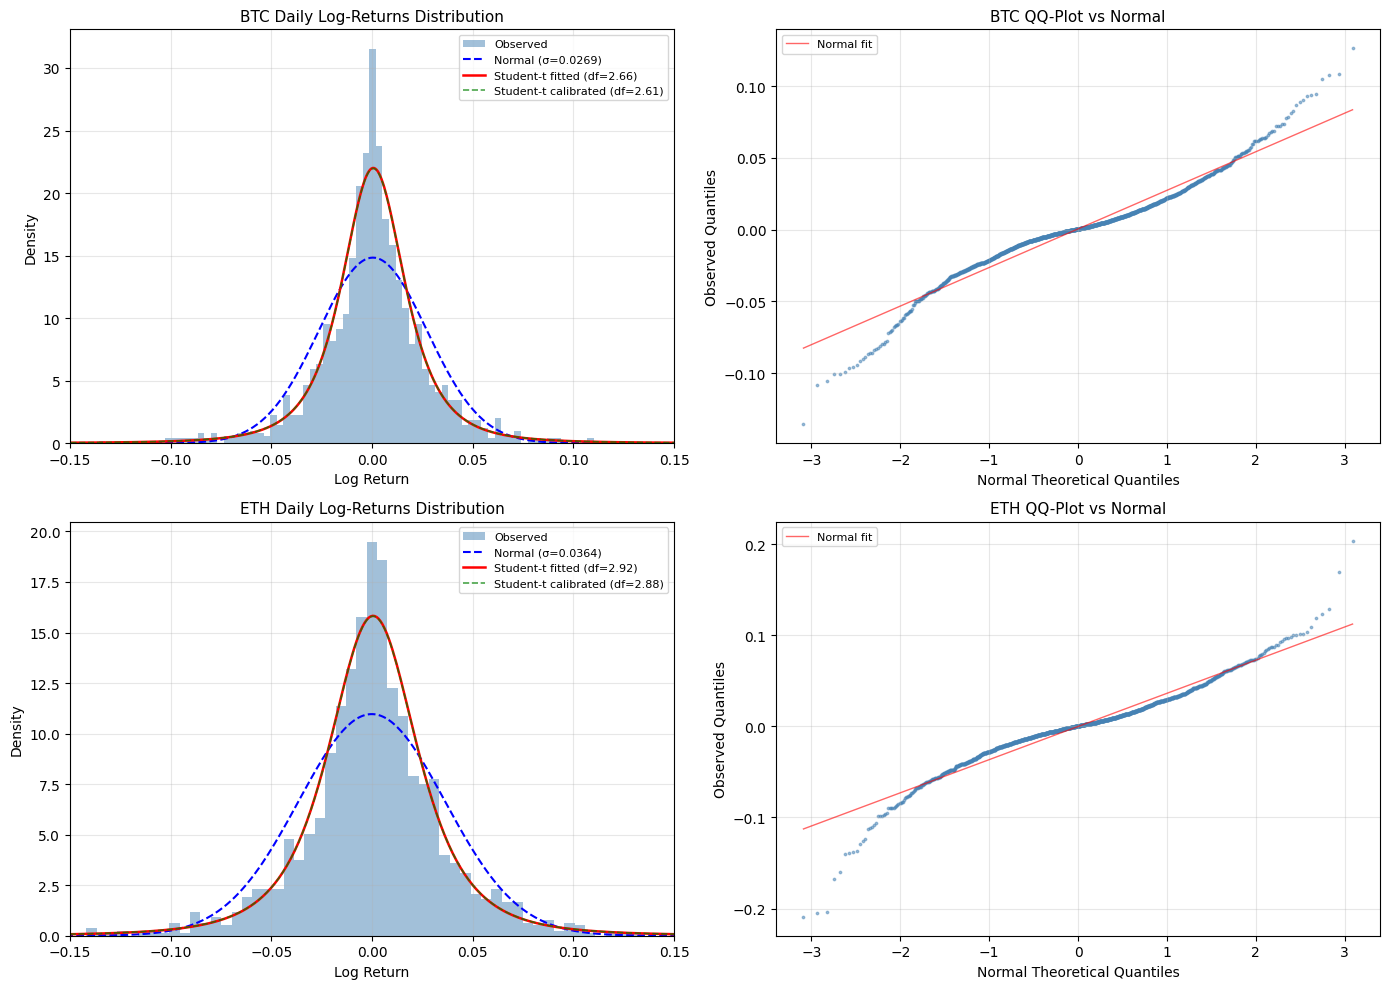

In [5]:
from trading_bot.market_data.deribit import deribit_get

CALIBRATED_DF = {'BTC': 2.61, 'ETH': 2.88}

def fetch_daily_returns(currency, days=1500):
    """Fetch daily close prices from Deribit and compute log-returns."""
    now_ms = int(datetime.now(timezone.utc).timestamp() * 1000)
    start_ms = now_ms - days * 86400 * 1000

    result = deribit_get(
        f'get_tradingview_chart_data?instrument_name={currency}-PERPETUAL'
        f'&resolution=1D&start_timestamp={start_ms}&end_timestamp={now_ms}'
    )
    closes = np.array(result['close'])
    log_ret = np.diff(np.log(closes))
    return log_ret, closes

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, currency in enumerate(['BTC', 'ETH']):
    print(f'Fetching {currency} daily data...')
    returns, closes = fetch_daily_returns(currency)

    # Fit distributions
    t_df, t_loc, t_scale = student_t.fit(returns)
    n_loc, n_scale = norm.fit(returns)

    cal_df = CALIBRATED_DF[currency]

    # === Left: Histogram + PDF overlays ===
    ax = axes[row, 0]
    x = np.linspace(returns.min() * 1.2, returns.max() * 1.2, 500)

    ax.hist(returns, bins=80, density=True, alpha=0.5, color='steelblue', label='Observed')
    ax.plot(x, norm.pdf(x, n_loc, n_scale), 'b--', linewidth=1.5, label=f'Normal (σ={n_scale:.4f})')
    ax.plot(x, student_t.pdf(x, t_df, t_loc, t_scale), 'r-', linewidth=1.8,
            label=f'Student-t fitted (df={t_df:.2f})')
    ax.plot(x, student_t.pdf(x, cal_df, t_loc, t_scale), 'g--', linewidth=1.2,
            label=f'Student-t calibrated (df={cal_df})', alpha=0.7)

    ax.set_title(f'{currency} Daily Log-Returns Distribution', fontsize=11)
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Density')
    ax.set_xlim(-0.15, 0.15)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # === Right: QQ-plot vs Normal ===
    ax2 = axes[row, 1]
    sorted_ret = np.sort(returns)
    n = len(sorted_ret)
    theoretical_q = norm.ppf(np.linspace(0.001, 0.999, n))

    ax2.scatter(theoretical_q, sorted_ret, s=3, alpha=0.5, color='steelblue')
    # Reference line
    lim = max(abs(theoretical_q.min()), abs(theoretical_q.max()))
    ref_x = np.array([-lim, lim])
    ax2.plot(ref_x, ref_x * n_scale + n_loc, 'r-', linewidth=1, alpha=0.6, label='Normal fit')

    ax2.set_title(f'{currency} QQ-Plot vs Normal', fontsize=11)
    ax2.set_xlabel('Normal Theoretical Quantiles')
    ax2.set_ylabel('Observed Quantiles')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # Stats
    tail_3s_normal = 2 * norm.sf(3)  # P(|X| > 3σ) for normal
    tail_3s_student = 2 * student_t.sf(3 * n_scale / t_scale, t_df)  # scaled
    tail_ratio = tail_3s_student / tail_3s_normal if tail_3s_normal > 0 else float('inf')

    print(f'\n{currency}: {len(returns)} daily returns')
    print(f'  Fitted df = {t_df:.2f}  (calibrated: {cal_df})')
    print(f'  Mean: {returns.mean():.5f}  Std: {returns.std():.5f}')
    print(f'  Kurtosis: {float(np.mean((returns - returns.mean())**4) / returns.std()**4):.2f} (Normal=3)')
    print(f'  Tail weight at 3σ: Student-t is {tail_ratio:.1f}x heavier than Normal')

plt.tight_layout()
plt.show()

---
## 3. Текущие возможности — Edge & ROI

In [6]:
from trading_bot.pricing.fast_approx import (
    batch_fast_touch_probabilities, touch_above_gbm, touch_below_gbm,
)
from trading_bot.pricing.touch_prob import STUDENT_DF_BTC, STUDENT_DF_ETH

MIN_EDGE_NO = 0.05   # 5% for NO positions
MIN_EDGE_YES = 0.10  # 10% for YES (2x, time decay against)
MIN_APY = 0.30       # 30% annualized

# Refresh markets and Deribit if needed
if not pm.markets or pm.age_seconds > 300:
    print('Refreshing markets...')
    pm.update()

if deribit.btc_spot <= 0:
    print('Loading Deribit data...')
    deribit.update()

markets = pm.markets
btc_spot = deribit.btc_spot
eth_spot = deribit.eth_spot
btc_iv = deribit.btc_iv
eth_iv = deribit.eth_iv

print(f'BTC: ${btc_spot:,.0f} IV={btc_iv:.1%} | ETH: ${eth_spot:,.0f} IV={eth_iv:.1%}')
print(f'Markets: {len(markets)}')

# Filter active markets
active = [m for m in markets if m.days_remaining > 0 and m.yes_price > 0]
print(f'Active with prices: {len(active)}')

# Group by (currency, days)
from collections import defaultdict
groups = defaultdict(list)
for m in active:
    days = max(int(m.days_remaining), 1)
    groups[(m.currency, days)].append(m)

# Calculate touch probs and build results
results = []

for (currency, days), group in groups.items():
    spot = btc_spot if currency == 'BTC' else eth_spot
    iv = btc_iv if currency == 'BTC' else eth_iv
    df = STUDENT_DF_BTC if currency == 'BTC' else STUDENT_DF_ETH
    drift = deribit.drift_for_days(currency, days)
    T = days / 365 if days > 0 else 1/365

    strikes_above = [m.strike for m in group if m.is_up]
    strikes_below = [m.strike for m in group if not m.is_up]

    above_probs, below_probs = batch_fast_touch_probabilities(
        spot=spot, iv=iv, days=days,
        strikes_above=strikes_above,
        strikes_below=strikes_below,
        drift=drift, df=df,
    )

    for m in group:
        if m.is_up:
            touch_prob = above_probs.get(m.strike, 0)
            fair_price = touch_prob
            side = 'YES'
            market_price = m.yes_price
            gbm_touch = touch_above_gbm(spot, m.strike, iv, T, mu=drift)
            gbm_fair = gbm_touch
        else:
            touch_prob = below_probs.get(m.strike, 0)
            fair_price = 1 - touch_prob
            side = 'NO'
            market_price = 1 - m.yes_price
            gbm_touch = touch_below_gbm(spot, m.strike, iv, T, mu=drift)
            gbm_fair = 1 - gbm_touch

        # Skip resolved markets (fair = 100%)
        if fair_price >= 0.995:
            continue

        edge = fair_price - market_price
        gbm_edge = gbm_fair - market_price

        if 0 < market_price < 1:
            roi = (fair_price - market_price) / market_price
            gbm_roi = (gbm_fair - market_price) / market_price
            apy = roi / T
        else:
            roi = 0
            gbm_roi = 0
            apy = 0

        # Determine period label
        if days > 200:
            period = 'Annual'
        else:
            try:
                end_month = datetime.fromisoformat(m.end_date.replace('Z', '+00:00')).strftime('%b')
            except Exception:
                end_month = m.end_date[:7]
            period = end_month

        direction = '\u2191' if m.is_up else '\u2193'
        min_edge = MIN_EDGE_YES if side == 'YES' else MIN_EDGE_NO
        is_buy = edge >= min_edge and apy >= MIN_APY

        results.append({
            'market': f'{currency} {direction} ${m.strike:,.0f}',
            'period': period,
            'side': side,
            'pm_price': market_price,
            'fair': fair_price,
            'edge': edge,
            'gbm_edge': gbm_edge,
            'roi': roi,
            'gbm_roi': gbm_roi,
            'drift': drift,
            'apy': apy,
            'is_buy': is_buy,
            'currency': currency,
            'days': days,
        })

# Sort by edge descending
results.sort(key=lambda r: r['edge'], reverse=True)

# Build HTML table
rows_html = ''
for r in results:
    if r['is_buy']:
        style = 'background: #d4edda; font-weight: bold;'
    elif r['edge'] > 0.03:
        style = 'background: #fff3cd;'
    else:
        style = ''

    rows_html += f'''<tr style="{style}">
        <td>{r['market']}</td><td>{r['period']}</td><td>{r['side']}</td>
        <td style="text-align:right">{r['pm_price']:.0%}</td>
        <td style="text-align:right">{r['fair']:.0%}</td>
        <td style="text-align:right">{r['edge']:+.1%}</td>
        <td style="text-align:right">{r['roi']:+.0%}</td>
        <td style="text-align:right; color:#888;">{r['gbm_edge']:+.1%}</td>
        <td style="text-align:right; color:#888;">{r['gbm_roi']:+.0%}</td>
        <td style="text-align:right; color:#888;">{r['drift']:+.1%}</td>
    </tr>'''

buy_count = sum(1 for r in results if r['is_buy'])

display(HTML(f'''
<style>
    .scan-table {{ border-collapse: collapse; font-family: monospace; font-size: 13px; }}
    .scan-table th {{ background: #f0f0f0; padding: 4px 10px; text-align: left; border-bottom: 2px solid #ccc; }}
    .scan-table td {{ padding: 3px 10px; border-bottom: 1px solid #e0e0e0; }}
</style>
<table class="scan-table">
<tr>
    <th>Market</th><th>Period</th><th>Side</th><th>PM</th><th>Fair</th>
    <th>Edge</th><th>ROI</th>
    <th title="GBM Normal model edge" style="color:#888;">GBM Edge</th>
    <th title="GBM Normal model ROI" style="color:#888;">GBM ROI</th>
    <th title="Drift from futures curve" style="color:#888;">Drift</th>
</tr>
{rows_html}
</table>
<p style="font-family:monospace; font-size:12px; color:#888; margin-top:8px;">
Edge/ROI = Student-t model | GBM = Normal (Black-Scholes) model | Drift = futures curve /yr<br>
Total: {len(results)} markets | {buy_count} BUY candidates
(edge &ge; {MIN_EDGE_NO:.0%} NO / {MIN_EDGE_YES:.0%} YES, APY &ge; {MIN_APY:.0%})
</p>
'''))

BTC: $67,342 IV=64.4% | ETH: $1,969 IV=81.2%
Markets: 85
Active with prices: 85


Market,Period,Side,PM,Fair,Edge,ROI,GBM Edge,GBM ROI,Drift
"BTC ↓ $65,000",Apr,NO,16%,29%,+12.5%,+78%,-2.2%,-14%,+2.3%
"BTC ↓ $60,000",Apr,NO,52%,62%,+9.1%,+17%,-8.3%,-16%,+2.3%
"ETH ↓ $1,800",Apr,NO,34%,42%,+7.7%,+23%,-7.1%,-21%,+1.7%
"ETH ↓ $1,200",Apr,NO,92%,97%,+5.5%,+6%,+4.1%,+5%,+1.7%
"BTC ↓ $50,000",Apr,NO,88%,94%,+5.3%,+6%,-0.5%,-1%,+2.3%
"BTC ↓ $15,000",Annual,NO,93%,98%,+5.0%,+5%,+3.1%,+3%,+3.6%
"ETH ↓ $1,400",Apr,NO,85%,90%,+4.7%,+6%,-2.1%,-2%,+1.7%
"BTC ↓ $55,000",Apr,NO,79%,83%,+4.2%,+5%,-8.6%,-11%,+2.3%
"BTC ↓ $20,000",Annual,NO,90%,95%,+4.2%,+5%,-0.8%,-1%,+3.6%
"ETH ↓ $1,600",Apr,NO,68%,72%,+4.2%,+6%,-8.9%,-13%,+1.7%


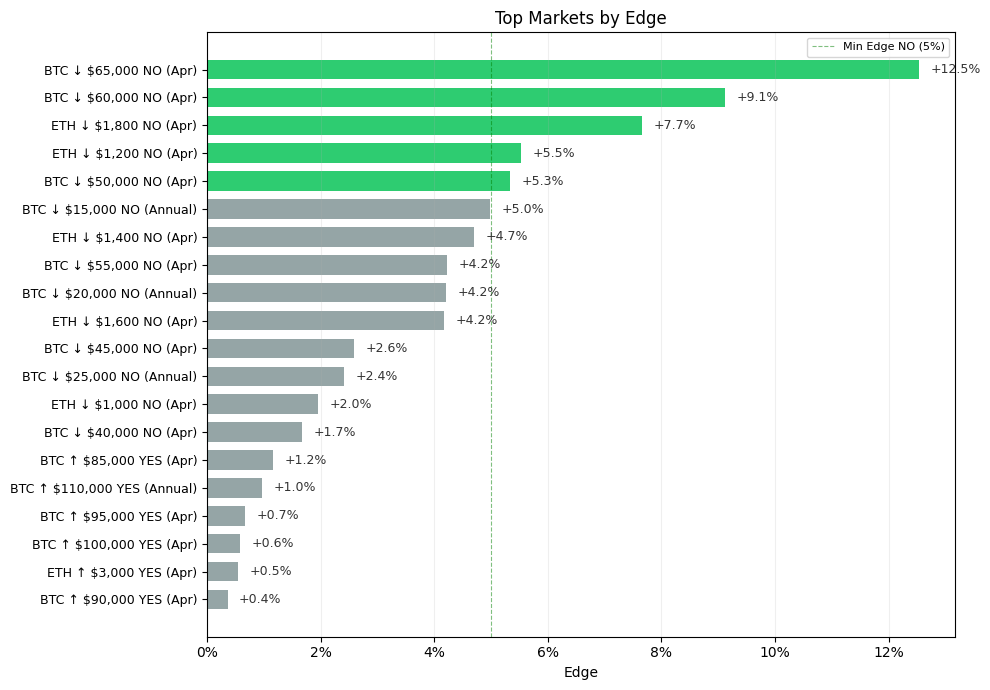

In [7]:
# === Visualization: Top markets by edge ===

top_n = [r for r in results if r['edge'] > 0][:20]
top_n.reverse()  # bottom to top

fig, ax = plt.subplots(figsize=(10, max(len(top_n) * 0.35, 4)))

labels = [f"{r['market']} {r['side']} ({r['period']})" for r in top_n]
edges = [r['edge'] for r in top_n]
colors = ['#2ecc71' if r['is_buy'] else '#95a5a6' for r in top_n]

ax.barh(range(len(top_n)), edges, color=colors, height=0.7)
ax.set_yticks(range(len(top_n)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_title('Top Markets by Edge', fontsize=12)
ax.set_xlabel('Edge')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.axvline(x=MIN_EDGE_NO, color='green', linewidth=0.8, linestyle='--', alpha=0.5, label=f'Min Edge NO ({MIN_EDGE_NO:.0%})')
ax.grid(True, alpha=0.2, axis='x')
ax.legend(fontsize=8)

for i, (e, r) in enumerate(zip(edges, top_n)):
    ax.text(e + 0.002, i, f'{e:+.1%}', va='center', fontsize=9, color='#333')

plt.tight_layout()
plt.show()